In [38]:
# Cellule 1 : Importations
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from scipy.stats import linregress
import time
import os
os.path.abspath("dynamical_exponent.ipynb")

'c:\\Users\\Benjamin Laier\\Uni\\Master Wien\\Semester V Erasmus\\Phase Transitions\\Project\\PhaseTransitionsProject\\dynamical_exponent.ipynb'

In [39]:
# Cellule 2 : Fonctions d'autocorrélation et de calcul de tau
def autocorrelation_fft(x, maxlag=None):
    x = np.asarray(x, dtype=float)
    n = x.size
    if maxlag is None:
        maxlag = n - 1
    mean = x.mean()
    x = x - mean
    m = 1 << (int(np.log2(2*n - 1)) + 1)
    fx = np.fft.rfft(x, n=m)
    acfull = np.fft.irfft(fx * np.conjugate(fx), n=m)[:n]
    acfull = acfull / n
    var = x.var()
    if var == 0:
        return np.ones(maxlag+1)
    ac = acfull[:maxlag+1] / var
    return ac

def integrated_tau_from_ac(ac, c_factor=5, max_iter=200):
    if len(ac) < 2:
        return 0.5
    tau = 0.5
    for _ in range(max_iter):
        W = min(len(ac)-1, max(1, int(c_factor * tau)))
        new_tau = 0.5 + np.sum(ac[1:W+1])
        if not np.isfinite(new_tau):
            return np.inf
        if abs(new_tau - tau) < 1e-6:
            return new_tau
        tau = new_tau
    return tau

def iterative_burn_and_tau(observable, c_factor=3, max_iter=10, min_fraction=0.001, verbose=False):
    n = len(observable)
    burn = 0
    prev_burn = -1
    tau = None

    for it in range(max_iter):
        data = observable[burn:]
        if len(data) < max(100, int(min_fraction * n)):
            if verbose:
                print(f"  [iter {it}] série restante trop courte ({len(data)}), stop.")
            break

        maxlag = min(len(data)-1, max(100, len(data)//10, 1000))
        ac = autocorrelation_fft(data, maxlag=maxlag)
        tau = integrated_tau_from_ac(ac, c_factor=c_factor)

        if not np.isfinite(tau) or tau <= 0:
            if verbose:
                print(f"  [iter {it}] τ invalid (tau={tau}), abort iteration.")
            tau = np.inf
            break

        new_burn = int(c_factor * tau)
        if verbose:
            print(f"  [iter {it}] len(data)={len(data)}, tau={tau:.3f}, new_burn={new_burn}")

        if new_burn >= len(observable):
            if verbose:
                print(f"  new_burn ({new_burn}) >= série totale ({len(observable)}): abort.")
            burn = len(observable)
            tau = np.inf
            break

        if new_burn == prev_burn:
            burn = new_burn
            break

        prev_burn = new_burn
        burn = new_burn

    data = observable[burn:]
    if len(data) < max(100, int(min_fraction * n)):
        if verbose:
            print(f"  Final: série restante trop courte ({len(data)}). τ non calculé.")
        return burn, np.inf, np.array([np.nan])

    maxlag = min(len(data)-1, 10000, max(100, len(data)//10))
    ac = autocorrelation_fft(data, maxlag=maxlag)
    tau = integrated_tau_from_ac(ac, c_factor=c_factor)

    return burn, tau, ac


In [40]:
# Cellule 3 : Configuration des données
base_dir = "data/Metropolis_Temp_Scan_3_Million_Sweeps"
beta_c = 0.4407
h = 0.0

L_list = []
for folder in os.listdir(base_dir):
    m = re.match(r"L_(\d+)", folder)
    if m:
        L_list.append(int(m.group(1)))
L_list = sorted(L_list)
print("Tailles détectées :", L_list)


Tailles détectées : [2, 4, 8, 16, 32, 64, 128]


In [41]:
# replace data for L=2 with 600,000 sweeps
print(L_list)

[2, 4, 8, 16, 32, 64, 128]


In [44]:
# Cellule 4 : Boucle principale de traitement
tau_vs_L = [[], []]
skipped = []

start_all = time.time()
for L in L_list:
    print(f"\n===== Traitement L = {L} =====")
    file_path = f"{base_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"
    if not os.path.exists(file_path):
        print(f"⚠️ Fichier absent : {file_path}")
        skipped.append((L, "missing file"))
        continue

    data = np.load(file_path)
    
    # use alternative data for L=2
    # if L == 2:
    #     # use data with 600,000 sweeps
    #     alt_dir = "data/Metropolis_Temp_Scan"
    #     file_path = f"{alt_dir}/L_{L}/h_{h}/mag_eng_beta_{beta_c:.4f}.npz"
    #     data = np.load(file_path)
    for i,observable in enumerate(["magnetizations", "energies"]):
        print(f"\n--- Analyse de '{observable}' ---")
        if observable not in data:
            print(f"⚠️ Donnée absente '{observable}' dans le fichier : {file_path}")
            skipped.append((L, f"missing_{observable}"))
            continue
        mags_engs = data[observable]
        N = len(mags_engs)
        print(f"Longueur série = {N}")

        t0 = time.time()
        burn, tau, ac = iterative_burn_and_tau(mags_engs, c_factor=3, min_fraction=0.001, verbose=True)
        dt = time.time() - t0

        if not np.isfinite(tau):
            print(f"  → τ invalide (tau={tau}). On ignore cette taille.")
            skipped.append((L, f"tau_bad_{tau}_for_{observable}"))
            continue

        min_points_required = 50 * tau
        if N < min_points_required:
            print(f"  → série trop courte pour L={L} (N={N}, tau≈{tau:.1f}, requis > {min_points_required:.0f})")
            skipped.append((L, f"series_too_short_for_{observable}"))
            continue

        print(f"Burn-in optimisé : {burn}")
        print(f"τ_int estimé = {tau:.4f}  (temps calcul: {dt:.1f}s)")
        tau_vs_L[i].append((L, tau))
total_time = time.time() - start_all
print(f"\nTotal runtime: {total_time:.1f}s")



===== Traitement L = 2 =====

--- Analyse de 'magnetizations' ---
Longueur série = 3000000
  [iter 0] len(data)=3000000, tau=3.912, new_burn=11
  [iter 1] len(data)=2999989, tau=3.912, new_burn=11
Burn-in optimisé : 11
τ_int estimé = 3.9125  (temps calcul: 2.3s)

--- Analyse de 'energies' ---
Longueur série = 3000000
  [iter 0] len(data)=3000000, tau=0.447, new_burn=1
  [iter 1] len(data)=2999999, tau=0.447, new_burn=1
Burn-in optimisé : 1
τ_int estimé = 0.4468  (temps calcul: 2.5s)

===== Traitement L = 4 =====

--- Analyse de 'magnetizations' ---
Longueur série = 3000000
  [iter 0] len(data)=3000000, tau=18.200, new_burn=54
  [iter 1] len(data)=2999946, tau=18.200, new_burn=54
Burn-in optimisé : 54
τ_int estimé = 18.1999  (temps calcul: 2.3s)

--- Analyse de 'energies' ---
Longueur série = 3000000
  [iter 0] len(data)=3000000, tau=1.188, new_burn=3
  [iter 1] len(data)=2999997, tau=1.188, new_burn=3
Burn-in optimisé : 3
τ_int estimé = 1.1876  (temps calcul: 2.2s)

===== Traitement L

In [49]:
# Cellule 5 : Vérification et sauvegarde debug
print("\n=== Vérification finale des tailles ===")
print("Skipped L:", skipped)
print("L conservés pour le fit:", [l for l,_ in tau_vs_L[0]])

with open("tau_vs_L_debug.txt", "w") as f:
    f.write("Skipped L:\n")
    for s in skipped:
        f.write(f"{s}\n")
    f.write("\nL conservés pour le fit:\n")
    # magnetizations
    for l, t in tau_vs_L[0]:
        f.write(f"L={l}, tau={t}\n")
    # energies
    for l, t in tau_vs_L[1]:
        f.write(f"L={l}, tau={t}\n")



=== Vérification finale des tailles ===
Skipped L: []
L conservés pour le fit: [2, 4, 8, 16, 32, 64, 128]



Estimated Dynamical Critical Exponent for Energy: z = 1.191
Coefficient R² = 0.9953


Estimated Dynamical Critical Exponent for Magnetization: z = 1.900
Coefficient R² = 0.9923



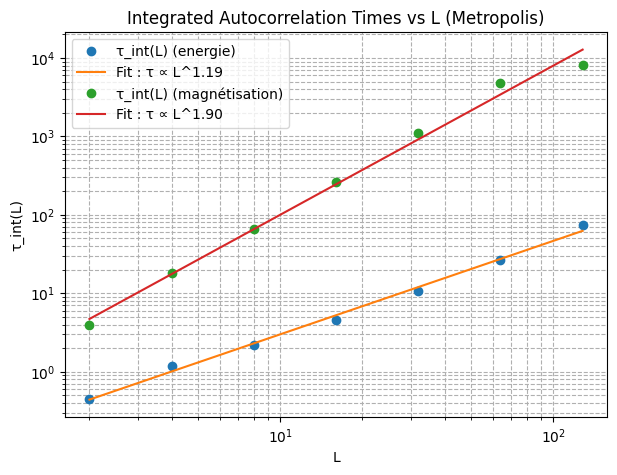

In [50]:
# Cellule 6 : Fit et visualisation
if len(tau_vs_L) < 2:
    print("Pas assez de points valides pour faire le fit.")
else:
    tau_vs_L = np.array(tau_vs_L)
    Ls = tau_vs_L[1, :, 0]
    taus_eng = tau_vs_L[1, :, 1]
    taus_mag = tau_vs_L[0, :, 1]

    logL = np.log(Ls)
    logtau_eng = np.log(taus_eng)
    logtau_mag = np.log(taus_mag)

    slope_eng, intercept_eng, r_value_eng, p_value_eng, std_err_eng = linregress(logL, logtau_eng)
    z_eng = slope_eng
    slope_mag, intercept_mag, r_value_mag, p_value_mag, std_err_mag = linregress(logL, logtau_mag)
    z_mag = slope_mag

    print("\n======================================")
    print(f"Estimated Dynamical Critical Exponent for Energy: z = {z_eng:.3f}")
    print(f"Coefficient R² = {r_value_eng**2:.4f}")
    print("======================================\n")

    print("\n======================================")
    print(f"Estimated Dynamical Critical Exponent for Magnetization: z = {z_mag:.3f}")
    print(f"Coefficient R² = {r_value_mag**2:.4f}")
    print("======================================\n")

    plt.close('all')
    plt.figure(figsize=(7,5))
    plt.loglog(Ls, taus_eng, 'o', label="τ_int(L) (energie)")
    plt.loglog(Ls, np.exp(intercept_eng) * Ls**z_eng, label=f"Fit : τ ∝ L^{z_eng:.2f}")
    plt.loglog(Ls, taus_mag, 'o', label="τ_int(L) (magnétisation)")
    plt.loglog(Ls, np.exp(intercept_mag) * Ls**z_mag, label=f"Fit : τ ∝ L^{z_mag:.2f}")
    plt.xlabel("L")
    plt.ylabel("τ_int(L)")
    plt.title("Integrated Autocorrelation Times vs L (Metropolis)")
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()
